In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import dask
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import time

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster

In [6]:
import os
S3_USER_STORAGE_KEY = os.environ["S3_USER_STORAGE_KEY"]
S3_USER_STORAGE_SECRET = os.environ["S3_USER_STORAGE_SECRET"]
S3_USER_STORAGE_BUCKET = os.environ["S3_USER_STORAGE_BUCKET"]

In [7]:
irr_store = new_data_store("s3",
                       root=S3_USER_STORAGE_BUCKET,
                       max_depth=5,
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [8]:
list(irr_store.get_data_ids())

['calibrated.zarr',
 'calibrated_0.zarr',
 'calibrated_1.zarr',
 'calibrated_10.zarr',
 'calibrated_11.zarr',
 'calibrated_12.zarr',
 'calibrated_13.zarr',
 'calibrated_14.zarr',
 'calibrated_15.zarr',
 'calibrated_16.zarr',
 'calibrated_17.zarr',
 'calibrated_18.zarr',
 'calibrated_19.zarr',
 'calibrated_2.zarr',
 'calibrated_20.zarr',
 'calibrated_3.zarr',
 'calibrated_4.zarr',
 'calibrated_5.zarr',
 'calibrated_6.zarr',
 'calibrated_7.zarr',
 'calibrated_8.zarr',
 'calibrated_9.zarr',
 'clms/clms_sm-2016_01_01-2016_01_30.zarr',
 'clms/clms_sm-2016_01_31-2016_02_29.zarr',
 'clms/clms_sm-2016_03_01-2016_03_30.zarr',
 'clms/clms_sm-2016_03_31-2016_04_29.zarr',
 'clms/clms_sm-2016_04_30-2016_05_29.zarr',
 'clms/clms_sm-2016_05_30-2016_06_28.zarr',
 'clms/clms_sm-2016_06_29-2016_07_28.zarr',
 'clms/clms_sm-2016_07_29-2016_08_27.zarr',
 'clms/clms_sm-2016_08_28-2016_09_26.zarr',
 'clms/clms_sm-2016_09_27-2016_10_26.zarr',
 'clms/clms_sm-2016_10_27-2016_11_25.zarr',
 'clms/clms_sm-2016_11_

In [5]:
# bbox = [-29, 25, 42, 83] # Europe
# bbox = [-25, 45, 34, 72]
# time_range = ("2017-02-24", "2025-09-30")
time_range = ("2023-06-18", "2025-09-30")

In [6]:
def split_date_range(start_date, end_date, num_days=30):
    if isinstance(start_date, str):
        start_date = datetime.strptime(start_date, "%Y-%m-%d")
    if isinstance(end_date, str):
        end_date = datetime.strptime(end_date, "%Y-%m-%d")
    
    result = []
    current = start_date
    
    while current <= end_date:
        chunk_end = min(current + timedelta(days=num_days - 1), end_date)
        result.append((current.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")))
        current = chunk_end + timedelta(days=1)
    
    return result

In [7]:
time_ranges = split_date_range(time_range[0], time_range[1], 5)
time_ranges, len(time_ranges)

([('2023-06-18', '2023-06-22'),
  ('2023-06-23', '2023-06-27'),
  ('2023-06-28', '2023-07-02'),
  ('2023-07-03', '2023-07-07'),
  ('2023-07-08', '2023-07-12'),
  ('2023-07-13', '2023-07-17'),
  ('2023-07-18', '2023-07-22'),
  ('2023-07-23', '2023-07-27'),
  ('2023-07-28', '2023-08-01'),
  ('2023-08-02', '2023-08-06'),
  ('2023-08-07', '2023-08-11'),
  ('2023-08-12', '2023-08-16'),
  ('2023-08-17', '2023-08-21'),
  ('2023-08-22', '2023-08-26'),
  ('2023-08-27', '2023-08-31'),
  ('2023-09-01', '2023-09-05'),
  ('2023-09-06', '2023-09-10'),
  ('2023-09-11', '2023-09-15'),
  ('2023-09-16', '2023-09-20'),
  ('2023-09-21', '2023-09-25'),
  ('2023-09-26', '2023-09-30'),
  ('2023-10-01', '2023-10-05'),
  ('2023-10-06', '2023-10-10'),
  ('2023-10-11', '2023-10-15'),
  ('2023-10-16', '2023-10-20'),
  ('2023-10-21', '2023-10-25'),
  ('2023-10-26', '2023-10-30'),
  ('2023-10-31', '2023-11-04'),
  ('2023-11-05', '2023-11-09'),
  ('2023-11-10', '2023-11-14'),
  ('2023-11-15', '2023-11-19'),
  ('2023

In [17]:
time_ranges[325]

('2021-08-07', '2021-08-11')

In [8]:
clms_store = new_data_store("s3",
                       root=os.path.join(S3_USER_STORAGE_BUCKET, "clms"),
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [9]:
json_file_path = "credentials.json"
with open(json_file_path, "r") as j:
    credentials = json.loads(j.read())

In [10]:
%%time
clms_data_store = new_data_store("clms", credentials=credentials)

CPU times: user 283 ms, sys: 65.2 ms, total: 348 ms
Wall time: 24.1 s


In [24]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

In [14]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)

In [15]:
debug_loggers = [
    "xcube",
    "xcube.clms",
    "xarray",
    "fsspec",
]
for name in debug_loggers:
    logging.getLogger(name).setLevel(logging.DEBUG)

In [11]:
%%time
 
for i, _time_range in enumerate(time_ranges):
    while True:
        try:
            print("Reading time_range:", _time_range)
            clms_data = clms_data_store.open_data(
                "daily-surface-soil-moisture-v1.0",
                time_range=_time_range
            )

            print("Writing data...")
            filename = f"clms_sm-{_time_range[0].replace('-', '_')}-{_time_range[1].replace('-', '_')}.zarr"
            clms_store.write_data(clms_data, filename, replace=True)

            print("Done:", _time_range)
            
            # force refresh of clms data store
            if i % 10 == 0:
                clms_data_store = new_data_store("clms", credentials=credentials)
            time.sleep(20)
            break
        except Exception as e:
            print(f"Exception for {_time_range}: {e}")
            print("Waiting 45 seconds before retrying...")
            time.sleep(45)

Reading time_range: ('2023-06-18', '2023-06-22')


/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube_clms/utils.py:674: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(batch_paths, engine=engine, **kwargs)


Writing data...
Done: ('2023-06-18', '2023-06-22')
Reading time_range: ('2023-06-23', '2023-06-27')


/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube_clms/utils.py:674: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(batch_paths, engine=engine, **kwargs)


Writing data...
Done: ('2023-06-23', '2023-06-27')
Reading time_range: ('2023-06-28', '2023-07-02')


...

Writing data...
Done: ('2025-09-20', '2025-09-24')
Reading time_range: ('2025-09-25', '2025-09-29')


/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube_clms/utils.py:674: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(batch_paths, engine=engine, **kwargs)


Writing data...
Done: ('2025-09-25', '2025-09-29')
Reading time_range: ('2025-09-30', '2025-09-30')


/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/xcube_clms/utils.py:722: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined_ds = xr.concat(datasets, dim="time")


Writing data...
Done: ('2025-09-30', '2025-09-30')
CPU times: user 10min 19s, sys: 1min 12s, total: 11min 32s
Wall time: 1h 19min 53s


In [9]:
# Missing dates from source - '2020-07-18', '2021-05-31' when running this for 2 years from 2020-2021

In [5]:
clms_store = new_data_store("s3",
                       root=S3_USER_STORAGE_BUCKET+"/clms",
                       max_depth=5,
                       storage_options=dict(anon=False,
                                            key=S3_USER_STORAGE_KEY,
                                            secret=S3_USER_STORAGE_SECRET))

In [6]:
data_ids = clms_store.list_data_ids()

In [7]:
times = []
for i, path in enumerate(data_ids):
    # print(i)
    ds = clms_store.open_data(path)
    t = pd.to_datetime(ds.time.values)
    times.extend(t)
    ds.close()

times = pd.to_datetime(times)
times = np.unique(times)

In [8]:
full_range = pd.date_range(times.min(), times.max(), freq='1D')
missing = full_range.difference(times)

print(f"Found {len(times)} unique timestamps")
print(f"Missing {len(missing)} dates:")
print(missing)

Found 3516 unique timestamps
Missing 45 dates:
DatetimeIndex(['2016-06-17', '2016-06-18', '2016-06-19', '2016-06-20',
               '2016-06-21', '2016-06-22', '2016-06-23', '2016-06-24',
               '2016-06-25', '2016-06-26', '2018-01-29', '2018-02-19',
               '2018-03-20', '2018-03-25', '2018-03-26', '2018-04-19',
               '2018-04-20', '2018-04-29', '2018-05-09', '2018-05-10',
               '2018-05-11', '2018-05-12', '2018-05-13', '2018-05-14',
               '2018-05-15', '2018-05-16', '2018-05-17', '2018-05-18',
               '2018-05-19', '2018-05-20', '2018-05-21', '2018-05-22',
               '2018-05-26', '2018-09-05', '2018-09-06', '2018-09-07',
               '2018-09-08', '2018-09-09', '2018-10-09', '2018-10-11',
               '2018-10-12', '2018-10-13', '2020-07-18', '2021-05-31',
               '2022-07-25'],
              dtype='datetime64[ns]', freq=None)


In [9]:
import pandas as pd
time = clms_data.time.values
full_range = pd.date_range(time.min(), time.max(), freq='1D')
missing = full_range.difference(time)
print(missing)

DatetimeIndex(['2016-06-17', '2016-06-18', '2016-06-19', '2016-06-20',
               '2016-06-21', '2016-06-22', '2016-06-23', '2016-06-24',
               '2016-06-25', '2016-06-26', '2018-01-29', '2018-02-19',
               '2018-03-20', '2018-03-25', '2018-03-26', '2018-04-19',
               '2018-04-20', '2018-04-29', '2018-05-09', '2018-05-10',
               '2018-05-11', '2018-05-12', '2018-05-13', '2018-05-14',
               '2018-05-15', '2018-05-16', '2018-05-17', '2018-05-18',
               '2018-05-19', '2018-05-20', '2018-05-21', '2018-05-22',
               '2018-05-26', '2018-09-05', '2018-09-06', '2018-09-07',
               '2018-09-08', '2018-09-09', '2018-10-09', '2018-10-11',
               '2018-10-12', '2018-10-13', '2020-07-18', '2021-05-31',
               '2022-07-25'],
              dtype='datetime64[ns]', freq=None)


In [10]:
clms_ssm_only = clms_data.drop_vars("ssm_noise") 
clms_ssm_only

<xarray.Dataset> Size: 398GB
Dimensions:  (time: 3516, lat: 4144, lon: 6832)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
Data variables:
    crs      (time) |S1 4kB b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b'' b''
    ssm      (time, lat, lon) float32 398GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2019
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2016-01-01T23:59:59Z
    time_coverage_start:       2016-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2016-01...

In [12]:
%%time
datasets = []
[datasets.append(clms_store.open_data(data_id).drop_vars("ssm_noise").astype('float32')) for data_id in sorted(data_ids)]
# datasets[:5]

CPU times: user 14.1 s, sys: 485 ms, total: 14.6 s
Wall time: 1min 33s


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [17]:
def get_dataset(data_id: str):
    ds = clms_store.open_data(data_id)
    ds = ds.drop_vars(["ssm_noise"])
    ds['ssm'] = ds['ssm'].astype("float32")
    return ds

In [18]:
get_dataset(data_ids[0])

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 30, lat: 4144, lon: 6832)
Coordinates:
  * time     (time) datetime64[ns] 240B 2016-01-01 2016-01-02 ... 2016-01-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
Data variables:
    crs      (time) |S1 30B dask.array<chunksize=(30,), meta=np.ndarray>
    ssm      (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2019
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2016-01-01T23:59:59Z
    time_coverage_start:       2016-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2016-01...

In [8]:
len(datasets)

641

In [9]:
total_time_steps = sum(ds.sizes['time'] for ds in datasets)
print(total_time_steps)

3516


In [13]:
datasets[0]

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 30, lat: 4144, lon: 6832)
Coordinates:
  * time     (time) datetime64[ns] 240B 2016-01-01 2016-01-02 ... 2016-01-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
Data variables:
    crs      (time) float32 120B dask.array<chunksize=(30,), meta=np.ndarray>
    ssm      (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2019
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2016-01-01T23:59:59Z
    time_coverage_start:       2016-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2016-01...

In [ ]:
# TODO:
# 1. Make spatial_ref the coordinate instead, ds = ds.assign_coords(spatial_ref=xr.DataArray(0, attrs=gm.crs.to_cf()))
# 2. Pop out crs

In [19]:
%%time
from zappend.api import zappend

config = {
    "target_dir": "s3://hub-deepesdl54/soil_moisture_zappend.zarr",
    "target_storage_options": {
        "anon": False,
        "key": S3_USER_STORAGE_KEY,
        "secret": S3_USER_STORAGE_SECRET,
    },
    "force_new": True,
    "logging": True,
    "excluded_variables": ["expver", "number"],
    "append_dim": "time",
    "variables": {
        "*": {
          "encoding": {
            "chunks": None
          }
        },
        "time": {
          "dims": ["time"],
          "encoding": {
            "chunks": [total_time_steps]
          }
        },
        "ssm": {
          "dims": ["time", "lat", "lon"],
          "encoding": {
            "chunks": [total_time_steps, 150, 150],
            "dtype": "float32",  
          },
    }
    }
}
zappend(data_ids, slice_source=get_dataset, config=config)

2025-10-20 15:58:55,664 WARNING Setting 'force_new' is enabled. This will permanently delete existing targets (no rollback).
2025-10-20 15:58:55,951 INFO Processing in-memory slice dataset #0
2025-10-20 15:58:56,004 INFO Creating target dataset s3://hub-deepesdl54/soil_moisture_zappend.zarr
/home/conda/deepesdl54/4162d0b2-1760697589-145-irrigation-eu/lib/python3.13/site-packages/zappend/processor.py:151: FutureWarning: zarr_version is deprecated, use zarr_format
  target_ds.to_zarr(
2025-10-20 15:59:49,779 INFO Transaction completed.
2025-10-20 15:59:49,780 INFO Slice dataset #0 processed
2025-10-20 15:59:50,118 INFO Processing in-memory slice dataset #1
2025-10-20 15:59:50,176 INFO Updating target dataset s3://hub-deepesdl54/soil_moisture_zappend.zarr
2025-10-20 16:01:27,784 INFO Transaction completed.
2025-10-20 16:01:27,785 INFO Slice dataset #1 processed
2025-10-20 16:01:28,100 INFO Processing in-memory slice dataset #2
2025-10-20 16:01:28,174 INFO Updating target dataset s3://hub-

CPU times: user 2d 5h 18min 11s, sys: 1d 19h 59min 26s, total: 4d 1h 17min 37s
Wall time: 1d 4h 52min 44s


641

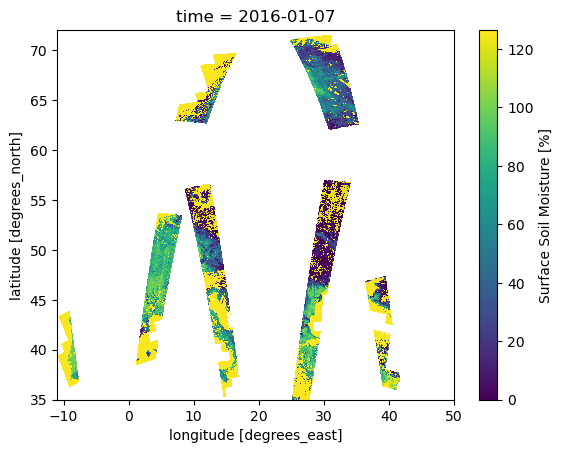

In [26]:
clms_ssm_only.isel(time=6).ssm.plot()

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example: open your dataset
# ds = xr.open_dataset("your_file.nc")

# Select the variable you want to plot
data = clms_ssm_only["ssm"].isel(time=6)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(10, 5),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the data
# Assume data has 'lat' and 'lon' dimensions
im = data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', 
               cbar_kwargs={'label': 'Variable Units'}, add_colorbar=True)

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Set map extent if you want (lon_min, lon_max, lat_min, lat_max)
# ax.set_extent([-25, 45, 34, 72], crs=ccrs.PlateCarree())

plt.title("Map of var_name")
plt.show()

In [11]:
dask.config.set(scheduler="single-threaded")

In [13]:
clms_ssm_only = chunk_dataset(clms_ssm_only, {"lat": 1382,"lon": 2278})
clms_ssm_only

<xarray.Dataset> Size: 398GB
Dimensions:  (time: 3516, lat: 4144, lon: 6832)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2016-01-01 2016-01-02 ... 2025-09-30
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
Data variables:
    crs      (time) |S1 4kB dask.array<chunksize=(3516,), meta=np.ndarray>
    ssm      (time, lat, lon) float32 398GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2019
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2016-01-01T23:59:59Z
    time_coverage_start:       2016-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2016-01...

In [16]:
%%time
irr_store.write_data(clms_ssm_only.astype("float32"), "soil_moisture_raw.zarr")

CPU times: user 6min 44s, sys: 13.9 s, total: 6min 58s
Wall time: 20min 22s


ClientResponseError: 429, message='Too Many Requests', url='https://globalland.vito.be/download/netcdf/surface_soil_moisture/ssm_1km_v1_daily/2017/20171231/c_gls_SSM1km_201712310000_CEURO_S1CSAR_V1.1.1.nc'

In [13]:
irr_store.list_data_ids()

['clms.zarr', 'era5.zarr']

In [14]:
irr_store.open_data("clms.zarr")

<xarray.Dataset> Size: 7GB
Dimensions:  (time: 31, lat: 4144, lon: 6832)
Coordinates:
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    crs      (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 7GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...